In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),                       
    transforms.Normalize((0.5, 0.5, 0.5),        
                         (0.5, 0.5, 0.5))         
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Training samples  : {len(train_dataset)}")
print(f"Test samples      : {len(test_dataset)}")
print(f"Train batches     : {len(train_loader)}")
print(f"Classes           : {train_dataset.classes}")

Device: cuda
Training samples  : 50000
Test samples      : 10000
Train batches     : 782
Classes           : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Batch shape : torch.Size([64, 3, 32, 32])
Labels shape: torch.Size([64])
One image shape: torch.Size([3, 32, 32])
Pixel range: -1.00 to 1.00


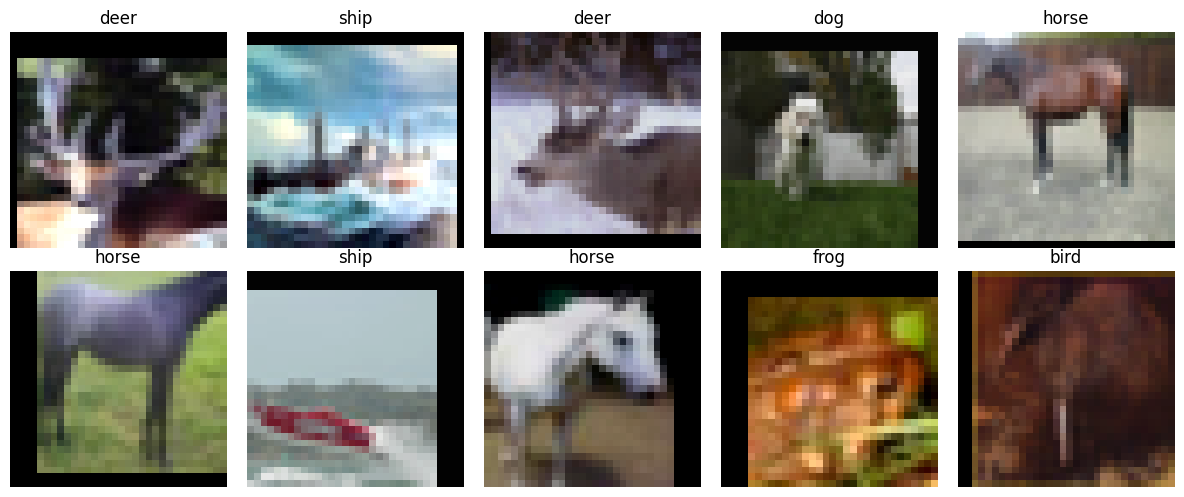

In [ ]:
images, labels = next(iter(train_loader))

print(f"Batch shape : {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"One image shape: {images[0].shape}")
print(f"Pixel range: {images.min():.2f} to {images.max():.2f}")

classes = train_dataset.classes
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i in range(10):
    img = images[i]
    img = img * 0.5 + 0.5  
    img = img.permute(1, 2, 0).numpy() 
    
    axes[i].imshow(img)
    axes[i].set_title(classes[labels[i]])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import torch.nn as nn

class CIFAR10_CNN(nn.Module):
    def __init__(self):
        super(CIFAR10_CNN, self).__init__()
        
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), 
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), 
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                          
            nn.Dropout2d(0.25)
        )
        
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1), 
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                        
            nn.Dropout2d(0.25)
        )
        
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                        
            nn.Dropout2d(0.25)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),                           
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)                       
        )
    
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

model = CIFAR10_CNN().to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

CIFAR10_CNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5)


print(f"Criterion : {criterion}")
print(f"Optimizer : Adam lr=0.001")

Criterion : CrossEntropyLoss()
Optimizer : Adam lr=0.001


In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct    = 0
    total      = 0
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)        
        loss    = criterion(outputs, labels) 
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        _, predicted = torch.max(outputs, 1)  
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()
        total_loss += loss.item()
    
    accuracy = 100 * correct / total
    avg_loss = total_loss / len(loader)
    return avg_loss, accuracy


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct    = 0
    total      = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs  = model(images)
            loss     = criterion(outputs, labels)
            
            _, predicted = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()
            total_loss += loss.item()
    
    accuracy = 100 * correct / total
    avg_loss = total_loss / len(loader)
    return avg_loss, accuracy

In [ ]:
n_epochs      = 50
best_val_acc  = 0.0
patience      = 7
patience_counter = 0
train_losses  = []
val_losses    = []
train_accs    = []
val_accs      = []

for epoch in range(n_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc     = evaluate(model, test_loader, criterion, device)
    
    scheduler.step(val_acc) 
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc     = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_cnn.pth')
    else:
        patience_counter += 1
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{n_epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.1f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.1f}% | "
              f"Patience: {patience_counter}/{patience}")
    
    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

model.load_state_dict(torch.load('best_cnn.pth'))
print(f"\nBest val accuracy: {best_val_acc:.2f}%")

Epoch   5/50 | Train Loss: 1.0284 | Train Acc: 64.1% | Val Loss: 0.8239 | Val Acc: 71.7% | Patience: 0/7
Epoch  10/50 | Train Loss: 0.8271 | Train Acc: 71.7% | Val Loss: 0.6489 | Val Acc: 77.8% | Patience: 0/7
Epoch  15/50 | Train Loss: 0.7144 | Train Acc: 75.4% | Val Loss: 0.6086 | Val Acc: 79.3% | Patience: 0/7
Epoch  20/50 | Train Loss: 0.6478 | Train Acc: 78.0% | Val Loss: 0.5690 | Val Acc: 80.9% | Patience: 0/7
Epoch  25/50 | Train Loss: 0.5963 | Train Acc: 79.5% | Val Loss: 0.5687 | Val Acc: 80.9% | Patience: 3/7
Epoch  30/50 | Train Loss: 0.5088 | Train Acc: 82.6% | Val Loss: 0.5140 | Val Acc: 82.8% | Patience: 0/7
Epoch  35/50 | Train Loss: 0.4732 | Train Acc: 83.8% | Val Loss: 0.5161 | Val Acc: 83.0% | Patience: 1/7
Epoch  40/50 | Train Loss: 0.4526 | Train Acc: 84.5% | Val Loss: 0.5204 | Val Acc: 83.0% | Patience: 2/7
Epoch  45/50 | Train Loss: 0.4135 | Train Acc: 85.6% | Val Loss: 0.5012 | Val Acc: 83.5% | Patience: 0/7
Epoch  50/50 | Train Loss: 0.3922 | Train Acc: 86.3% | 

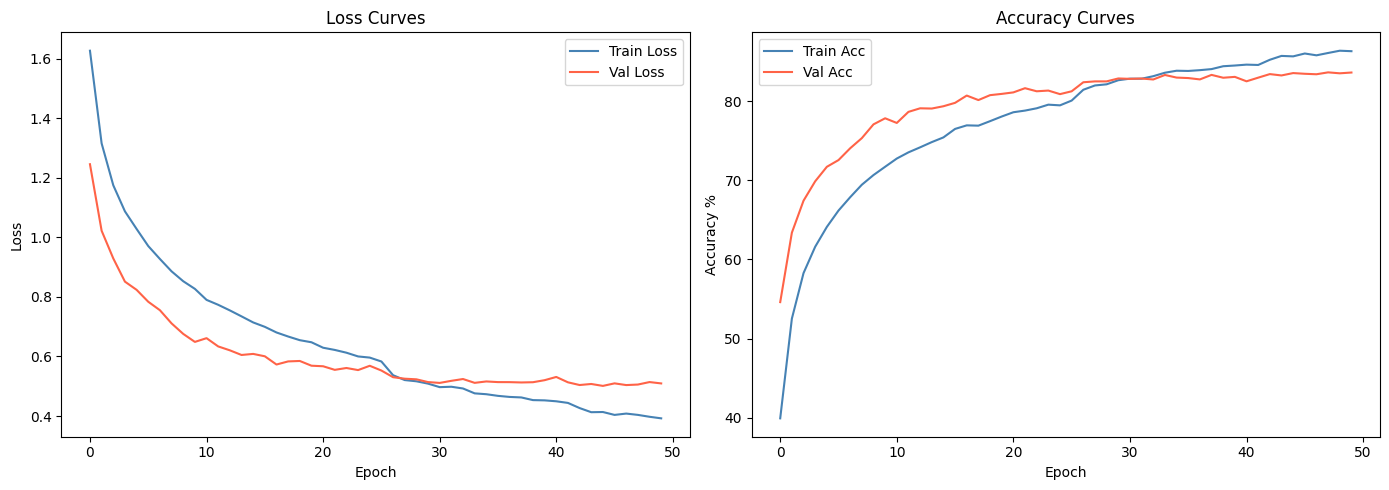

              precision    recall  f1-score   support

    airplane       0.86      0.83      0.85      1000
  automobile       0.94      0.91      0.92      1000
        bird       0.78      0.73      0.75      1000
         cat       0.71      0.68      0.69      1000
        deer       0.80      0.85      0.83      1000
         dog       0.78      0.76      0.77      1000
        frog       0.82      0.91      0.86      1000
       horse       0.89      0.86      0.87      1000
        ship       0.88      0.92      0.90      1000
       truck       0.90      0.91      0.90      1000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train Loss', color='steelblue')
axes[0].plot(val_losses,   label='Val Loss',   color='tomato')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves')
axes[0].legend()

axes[1].plot(train_accs, label='Train Acc', color='steelblue')
axes[1].plot(val_accs,   label='Val Acc',   color='tomato')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy %')
axes[1].set_title('Accuracy Curves')
axes[1].legend()

plt.tight_layout()
plt.show()

from sklearn.metrics import classification_report
import numpy as np

all_preds  = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, 
                            target_names=train_dataset.classes))

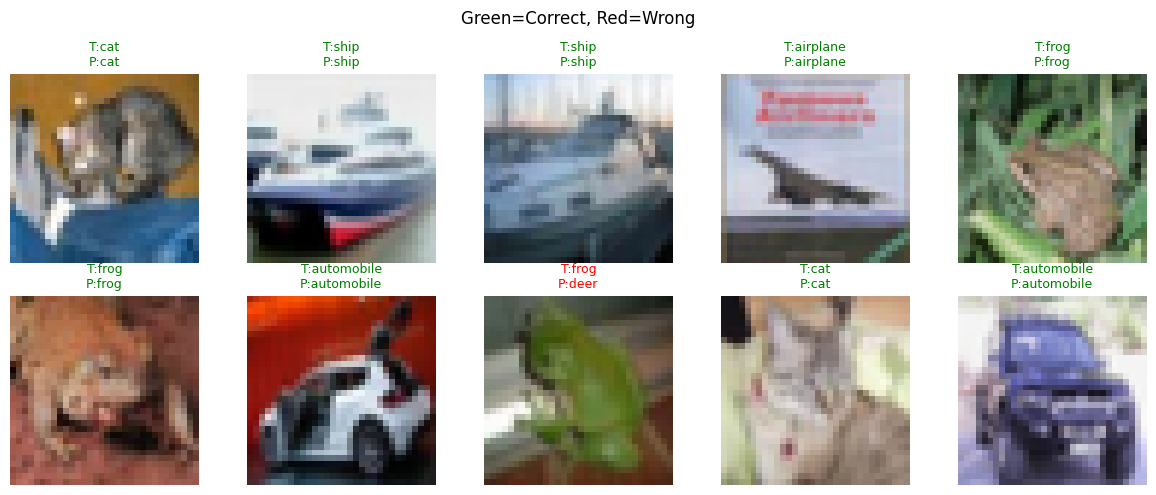

In [ ]:
model.eval()
images, labels = next(iter(test_loader))
images_gpu = images.to(device)

with torch.no_grad():
    outputs = model(images_gpu)
    _, predicted = torch.max(outputs, 1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i in range(10):
    img = images[i] * 0.5 + 0.5
    img = img.permute(1, 2, 0).numpy()
    
    true_label = train_dataset.classes[labels[i]]
    pred_label = train_dataset.classes[predicted[i].cpu()]
    correct    = labels[i] == predicted[i].cpu()
    
    axes[i].imshow(img)
    axes[i].set_title(f'T:{true_label}\nP:{pred_label}',
                      color='green' if correct else 'red',
                      fontsize=9)
    axes[i].axis('off')

plt.suptitle('Green=Correct, Red=Wrong')
plt.tight_layout()
plt.show()

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),          
    transforms.RandomCrop(32, padding=4),       
    transforms.ColorJitter(brightness=0.2,      
                          contrast=0.2,       
                          saturation=0.2),     
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), 
                         (0.5, 0.5, 0.5))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), 
                         (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=False, transform=train_transform)
test_dataset  = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=False, transform=test_transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

print("Transforms updated")

Transforms updated


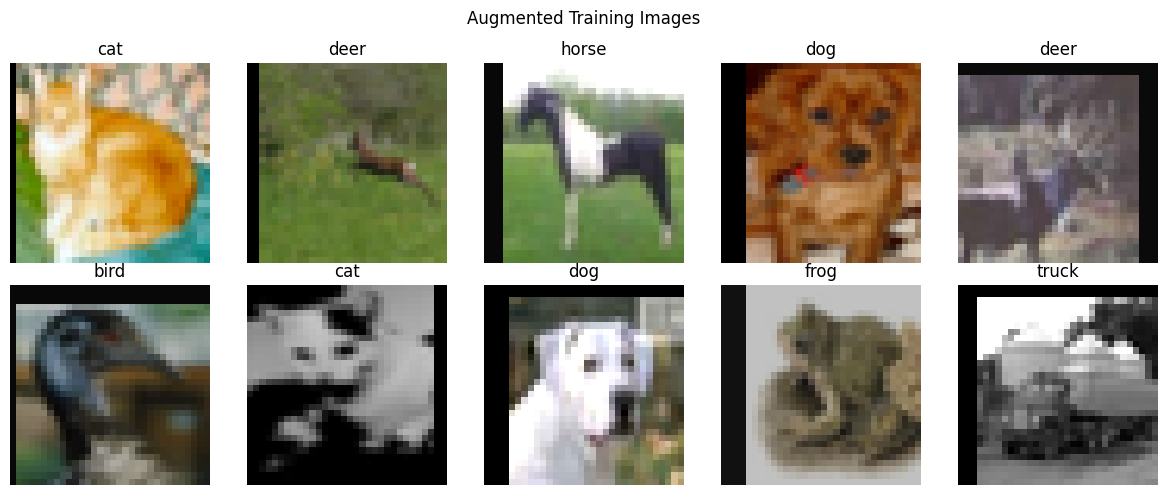

In [15]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i in range(10):
    img = images[i] * 0.5 + 0.5
    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    axes[i].imshow(img)
    axes[i].set_title(train_dataset.classes[labels[i]])
    axes[i].axis('off')

plt.suptitle('Augmented Training Images')
plt.tight_layout()
plt.show()

In [ ]:
model     = CIFAR10_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5)

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print("Ready to train with augmentation")

Parameters: 667,178
Ready to train with augmentation


In [ ]:
n_epochs      = 90
best_val_acc  = 0.0
patience      = 7
patience_counter = 0
train_losses  = []
val_losses    = []
train_accs    = []
val_accs      = []

for epoch in range(n_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc     = evaluate(model, test_loader, criterion, device)
    
    scheduler.step(val_acc) 
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc     = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_cnn.pth')
    else:
        patience_counter += 1
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{n_epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.1f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.1f}% | "
              f"Patience: {patience_counter}/{patience}")
    
    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

model.load_state_dict(torch.load('best_cnn.pth'))
print(f"\nBest val accuracy: {best_val_acc:.2f}%")

Epoch   5/90 | Train Loss: 0.6467 | Train Acc: 78.0% | Val Loss: 0.4698 | Val Acc: 84.0% | Patience: 1/7
Epoch  10/90 | Train Loss: 0.6258 | Train Acc: 78.5% | Val Loss: 0.4512 | Val Acc: 84.9% | Patience: 0/7
Epoch  15/90 | Train Loss: 0.6154 | Train Acc: 79.0% | Val Loss: 0.4496 | Val Acc: 85.0% | Patience: 0/7
Epoch  20/90 | Train Loss: 0.6001 | Train Acc: 79.5% | Val Loss: 0.4404 | Val Acc: 85.3% | Patience: 0/7
Epoch  25/90 | Train Loss: 0.5938 | Train Acc: 79.9% | Val Loss: 0.4377 | Val Acc: 85.4% | Patience: 1/7
Epoch  30/90 | Train Loss: 0.5858 | Train Acc: 80.1% | Val Loss: 0.4330 | Val Acc: 85.5% | Patience: 0/7
Epoch  35/90 | Train Loss: 0.5820 | Train Acc: 80.4% | Val Loss: 0.4287 | Val Acc: 85.4% | Patience: 4/7

Early stopping at epoch 38

Best val accuracy: 85.76%


In [ ]:
all_preds  = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds,
                            target_names=train_dataset.classes))

              precision    recall  f1-score   support

    airplane       0.86      0.87      0.87      1000
  automobile       0.93      0.95      0.94      1000
        bird       0.82      0.75      0.78      1000
         cat       0.75      0.70      0.72      1000
        deer       0.84      0.87      0.85      1000
         dog       0.81      0.77      0.79      1000
        frog       0.81      0.93      0.87      1000
       horse       0.91      0.89      0.90      1000
        ship       0.92      0.93      0.92      1000
       truck       0.91      0.93      0.92      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000

